## Parte 01 - Análise Exploratória

Este notebook organiza a análise exploratória dos chamados da Central 1746 com foco no problema de classificação automática. A ideia é entender o tamanho, a composição, a estabilidade e a qualidade textual da base antes de comparar os modelos A e B.

A análise prioriza evidências úteis para avaliar classificadores:
- desbalanceamento entre categorias, variações por canal, bairro e tempo,
- qualidade dos textos e sobreposição lexical entre classes\
‎ 

---
---

### **Importação de Pacotes e Funções Auxiliares**

**Objetivo:** carregar bibliotecas, configurar visualizações e definir utilitários usados ao longo da análise.

In [1]:
# Importa bibliotecas de manipulação, visualização, geoprocessamento e vetorização textual
import re
import math
import unicodedata
from pathlib import Path
from typing import Any, Literal, Optional, Sequence, Tuple, Union
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.cm as cm
import seaborn as sns
import geopandas as gpd
import warnings
from unidecode import unidecode
from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from functions import pretty_label, save_figure, load_and_prepare_data
# Importa recursos usados para montar a malha geográfica e normalizar a escala de cores dos mapas
import requests
from matplotlib.colors import Normalize
from shapely.geometry import Polygon
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
# Define diretórios de saída e parâmetros visuais padrão para manter os gráficos consistentes
output_dir = Path("../results")
fig_dir = output_dir / "figures/aedv"
fig_dir.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12

In [3]:
# Funções utilitárias para padronizar rótulos e formatar números em português
def remove_accent(texto: Any) -> Any:
    """Remove acentos de strings, preservando valores que não são texto."""
    if isinstance(texto, str):
        return ''.join(c for c in unicodedata.normalize('NFD', texto) if unicodedata.category(c) != 'Mn')
    return texto


def format_number_ptbr(valor: Union[int, float]) -> str:
    """Formata números inteiros com separador de milhar no padrão brasileiro."""
    return f"{valor:,.0f}".replace(",", ".")


def format_percentual_ptbr(valor: Union[int, float]) -> str:
    """Formata percentuais com uma casa decimal e vírgula decimal."""
    return f"{valor:.1f}%".replace(".", ",")

---
---
### **1. Leitura, Validação e Tratamento de Dados**

Este bloco valida a estrutura do dataset e confirma se os campos essenciais para a análise estão coerentes. Problemas de integridade, valores ausentes ou inconsistências de texto podem distorcer as distribuições e levar a conclusões erradas sobre a dificuldade do problema de classificação.

---
---

In [4]:
# Carrega a base já com os tratamentos auxiliares definidos no projeto
warnings.filterwarnings("ignore")
df = load_and_prepare_data('../dados/chamados_com_predicoes.csv')

#### **1.1 Visão Geral dos Dados**

As métricas iniciais verificam se a base é completa, se os identificadores são únicos e se os textos têm tamanho mínimo para sustentar classificação automática.

---

In [5]:
# Resume qualidade, cobertura temporal e tipos das colunas principais da base
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

sanity_metrics = [
    ("Tamanho (linhas, colunas)", df.shape),
    ("IDs de chamados duplicados", df["id_chamado"].duplicated().sum()),
    ("IDs de chamados com menos de 10 caracteres", df["id_chamado"].fillna("").astype(str).str.len().lt(10).sum()),
    ("Valores faltantes/NaN", df.isna().sum().sum()),
    ("Média do tamanho do texto em palavras", round(df["palavra_count"].mean(), 2)),
    ("Mediana do tamanho do texto em palavras", round(df["palavra_count"].median(), 2)),
    ("Textos muito curtos (<= 5 palavras) (%)", round(100 * df["bool_texto_curto"].mean(), 2)),
]

general_metrics = [
    ("Data de início", df["data_abertura"].min()),
    ("Data de término", df["data_abertura"].max()),
    ("Número de categorias", df["categoria_real"].nunique()),
    ("Número de categorias previstas", f"Modelo A: {df['pred_modelo_a'].nunique()}, Modelo B: {df['pred_modelo_b'].nunique()}"),
    ("Número de bairros", df["bairro"].nunique()),
    ("Número de canais", df["canal"].nunique()),
]

sanity_table = pd.DataFrame(sanity_metrics, columns=["Métrica", "Valor"])
metrics_table = pd.DataFrame(general_metrics, columns=["Métrica", "Valor"])

type_table = (
    df.dtypes.astype(str)
    .groupby(df.dtypes.astype(str))
    .apply(lambda x: list(x.index))
    .reset_index(name="Colunas")
    .rename(columns={"index": "Tipo"})
)

display(sanity_table)
display(metrics_table)
display(type_table)

pd.reset_option("display.max_colwidth")
pd.reset_option("display.width")

,Métrica,Valor
0,"Tamanho (linhas, colunas)","(5000, 16)"
1,IDs de chamados duplicados,0
2,IDs de chamados com menos de 10 caracteres,0
3,Valores faltantes/NaN,0
4,Média do tamanho do texto em palavras,23.26
5,Mediana do tamanho do texto em palavras,28.0
6,Textos muito curtos (<= 5 palavras) (%),2.4


,Métrica,Valor
0,Data de início,2026-01-01 00:00:00
1,Data de término,2026-06-30 00:00:00
2,Número de categorias,8
3,Número de categorias previstas,"Modelo A: 8, Modelo B: 8"
4,Número de bairros,15
5,Número de canais,3


,Tipo,Colunas
0,bool,[bool_texto_curto]
1,datetime64[ns],"[data_abertura, month, week]"
2,float64,"[conf_modelo_a, conf_modelo_b]"
3,int64,"[tamanho_texto_palavras, palavra_count]"
4,object,"[id_chamado, bairro, canal, texto, categoria_real, pred_modelo_a, pred_modelo_b, texto_limpo]"


---
---
### **2. Panorama Geral dos Chamados**
---
---

#### **2.1 Distribuição de Chamados por Categoria, Bairro e Canal**

**Objetivo:** identificar onde a demanda se concentra e se a base é balanceada.

**Importância:** um modelo pode parecer bom apenas por acertar categorias frequentes. A análise por canal e bairro também mostra se a linguagem dos chamados muda conforme a origem do pedido.

---

In [6]:
# Funções para resumir distribuições e padronizar gráficos de barras
def tabela_contagem_percentual(df: pd.DataFrame, coluna: str, ordenar: bool = True) -> pd.DataFrame:
    """Calcula frequência absoluta, percentual e percentual acumulado de uma coluna."""
    tabela = df[coluna].value_counts(dropna=False).rename_axis(coluna).reset_index(name="n")
    tabela["percentual"] = 100 * tabela["n"] / tabela["n"].sum()
    if ordenar:
        tabela = tabela.sort_values("n", ascending=False)
    tabela["percentual_acumulado"] = tabela["percentual"].cumsum()
    tabela[coluna] = tabela[coluna].astype(str)
    return tabela


def plotar_barras_horizontais(
    tabela: pd.DataFrame,
    coluna_categoria: str,
    coluna_valor: str,
    titulo: str,
    xlabel: str,
    nome_arquivo: str,
    top_n: Optional[int] = None,
    coluna_percentual: Optional[str] = None,
    cor: str = "#779FC9",
) -> None:
    """Gera gráfico de barras horizontais com rótulos de valor e percentual opcional."""
    dados = tabela.copy()
    if top_n is not None:
        dados = dados.head(top_n)

    dados = dados.sort_values(coluna_valor, ascending=True)
    valores = dados[coluna_valor].to_numpy()

    fig, ax = plt.subplots(figsize=(9, max(4, 0.42 * len(dados))))
    ax.barh(dados[coluna_categoria].map(pretty_label), valores, color=cor)
    xmax = valores.max()
    ax.set_xlim(0, xmax * 1.32)
    ax.set_title(titulo)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

    for i, (_, linha) in enumerate(dados.iterrows()):
        valor = linha[coluna_valor]
        texto = f" {format_number_ptbr(valor)}"
        if coluna_percentual is not None:
            texto += f" ({format_percentual_ptbr(linha[coluna_percentual])})"
        ax.text(valor, i, texto, va="center")
    ax.grid(False)
    save_figure(fig, fig_dir, nome_arquivo)
    plt.show()


def plotar_barras_verticais(
    tabela: pd.DataFrame,
    coluna_categoria: str,
    coluna_valor: str,
    titulo: str,
    xlabel: str,
    ylabel: str,
    nome_arquivo: str,
    top_n: Optional[int] = None,
    coluna_percentual: Optional[str] = None,
    cor: str = "#779FC9",
) -> None:
    """Gera gráfico de barras verticais com rótulos de valor e percentual opcional."""
    dados = tabela.copy()
    if top_n is not None:
        dados = dados.head(top_n)

    valores = dados[coluna_valor].to_numpy()
    categorias = dados[coluna_categoria].map(pretty_label)

    fig, ax = plt.subplots(figsize=(6, 4.5))
    ax.bar(categorias, valores, color=cor)

    ymax = valores.max()
    ax.set_ylim(0, ymax * 1.18)
    ax.set_title(titulo)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

    for i, (_, linha) in enumerate(dados.iterrows()):
        valor = linha[coluna_valor]
        texto = f"{format_number_ptbr(valor)}"
        if coluna_percentual is not None:
            texto += f" ({format_percentual_ptbr(linha[coluna_percentual])})"

        ax.text(i, valor, texto, ha="center", va="bottom")

    plt.xticks(rotation=0)
    fig.tight_layout()
    ax.grid(False)
    save_figure(fig, fig_dir, nome_arquivo)
    plt.show()

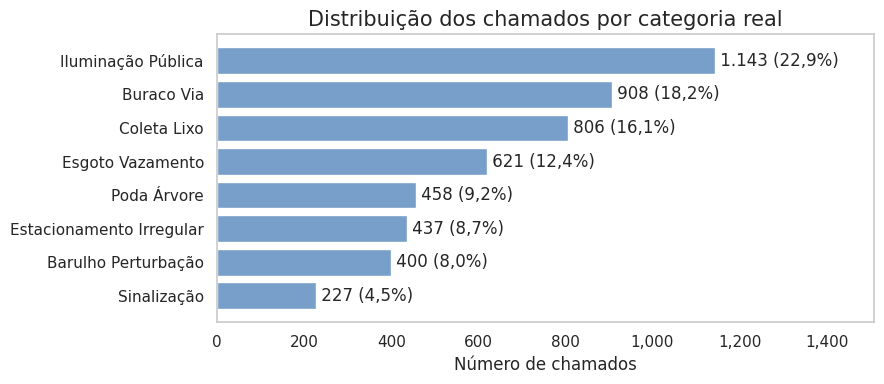

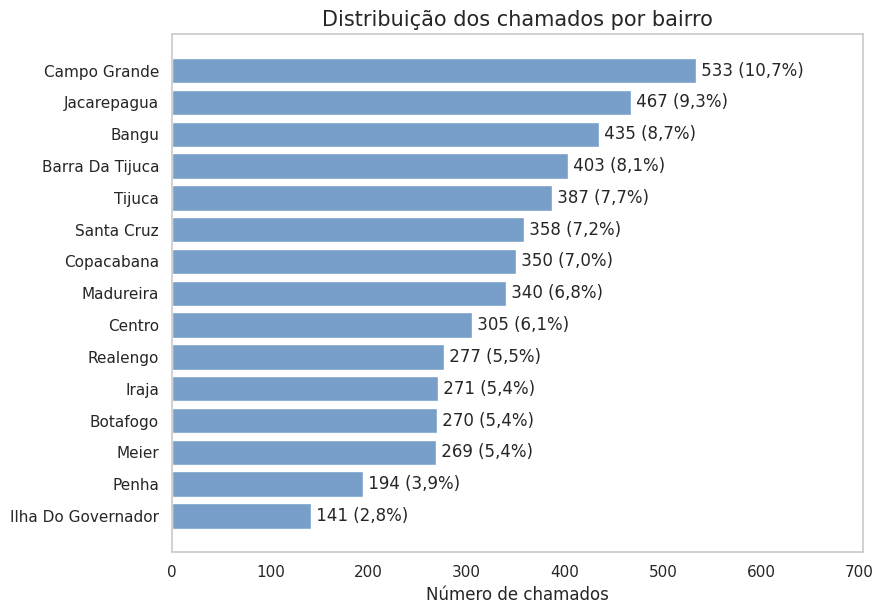

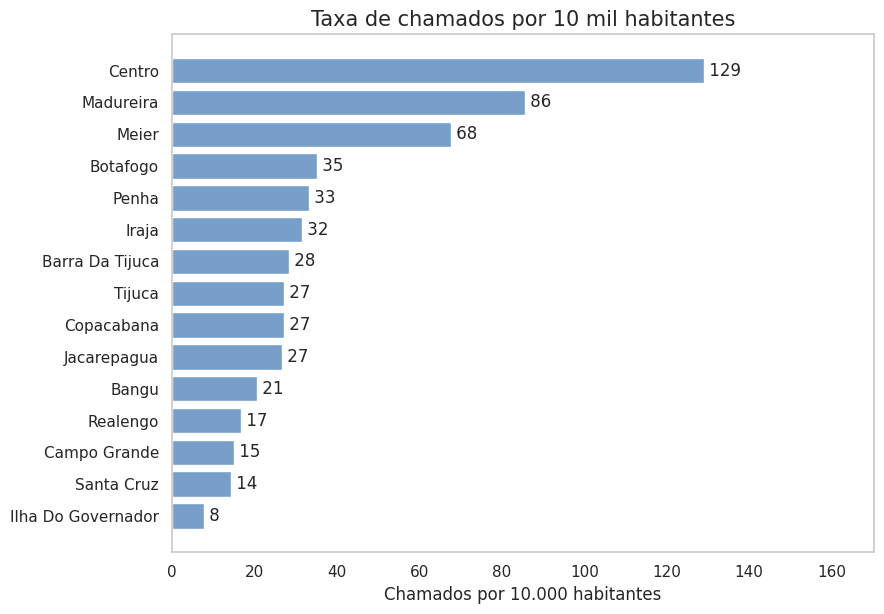

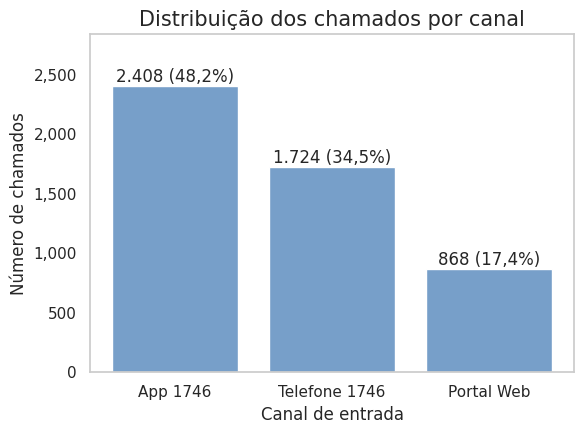

In [7]:
# Calcula frequências por categoria, bairro e canal; também normaliza bairros por população.
pop_bairros = pd.read_csv("../dados/censo2022.csv")
tabela_categorias = tabela_contagem_percentual(df, "categoria_real")
tabela_canais = tabela_contagem_percentual(df, "canal")
tabela_bairros = tabela_contagem_percentual(df, "bairro")
tabela_bairros_pop = (tabela_bairros.merge(pop_bairros[["bairro", "pop_bairro"]], on="bairro", how="left"))
tabela_bairros_pop["chamados_por_10k_hab"] = (tabela_bairros_pop["n"] / tabela_bairros_pop["pop_bairro"] * 10000)

plotar_barras_horizontais(
    tabela_categorias,"categoria_real","n",
    "Distribuição dos chamados por categoria real","Número de chamados",
    "02_barras_categorias_reais",
    coluna_percentual="percentual"
)

plotar_barras_horizontais(
    tabela_bairros,"bairro","n",
    "Distribuição dos chamados por bairro","Número de chamados",
    "02_barras_bairros",
    top_n=15,coluna_percentual="percentual"
)

plotar_barras_horizontais(
    tabela_bairros_pop,"bairro","chamados_por_10k_hab",
    "Taxa de chamados por 10 mil habitantes","Chamados por 10.000 habitantes",
    "02_barras_bairros_por_10mil_habitantes",
    top_n=15,coluna_percentual=None
)

plotar_barras_verticais(
    tabela_canais,"canal","n",
    "Distribuição dos chamados por canal","Canal de entrada","Número de chamados",
    "02_barras_canais",
    coluna_percentual="percentual"
)


**<u>Resultados:</u>**

- A distribuição por categoria é desbalanceada. `Iluminação Pública` concentra **1.143 chamados (22,9%)**, seguida por `Buraco Via` com **908 (18,2%)** e `Coleta Lixo` com **806 (16,1%)**; juntas, as três somam **57,2%** da base. No outro extremo, `Sinalização` tem apenas **227 chamados (4,5%)**, o que exige cuidado com métricas globais.

- Por bairro, o maior volume absoluto aparece em `Campo Grande` (**533; 10,7%**), `Jacarepaguá` (**467; 9,3%**) e `Bangu` (**435; 8,7%**). Quando normalizamos por população, a leitura muda: **Centro** lidera com **129 chamados por 10 mil habitantes**, seguido por **Madureira** (**86**) e **Méier** (**68**). Volume bruto e relativo contam histórias diferentes.

- Por canal, há forte predominância do `App 1746` com **2.408 chamados (48,2%)**, depois `Telefone 1746` com **1.724 (34,5%)** e `Portal Web` com **868 (17,4%)**. Na avaliação dos modelos, vamos checar se o desempenho se mantém nos três canais, especialmente porque o Portal representa uma fração menor da base.

#### **2.2 Série Temporal de Chamados**

**Objetivo:** verificar se a demanda é estável ou se existem oscilações relevantes ao longo do semestre.

**Importância:** se o volume ou a composição das categorias muda muito com o tempo, a avaliação dos classificadores precisa considerar drift temporal e não apenas métricas agregadas.

---

In [8]:
# Importa recursos usados para ajustar uma curva simples de tendência temporal.
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score

In [9]:
# Funções para selecionar uma tendência polinomial simples e plotar séries temporais.
def _melhor_grau(x: np.ndarray, y: np.ndarray, grau_max: int = 5) -> int:
    """Seleciona o grau polinomial com menor erro médio em validação cruzada."""
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    return min(
        range(1, grau_max + 1),
        key=lambda g: -cross_val_score(
            LinearRegression(),
            PolynomialFeatures(g, include_bias=False).fit_transform(x[:, None]),
            y, cv=kf, scoring="neg_mean_squared_error"
        ).mean())

def plotar_linha_temporal(
    tabela: pd.DataFrame,
    coluna_data: str,
    coluna_valor: str,
    titulo: str,
    ylabel: str,
    nome_arquivo: str,
    curva: Union[str, int, None] = "auto",
    grau_max: int = 5,
) -> None:
    """Plota uma série temporal agregada e, opcionalmente, uma curva de tendência."""
    tabela = tabela.sort_values(coluna_data)
    x = np.arange(len(tabela))
    y = tabela[coluna_valor].to_numpy()

    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.plot(tabela[coluna_data], y, marker="o", label="Observado")

    if curva is not None:
        grau = _melhor_grau(x, y, grau_max) if curva == "auto" else curva
        X = PolynomialFeatures(grau, include_bias=False).fit_transform(x[:, None])
        y_pred = LinearRegression().fit(X, y).predict(X)
        ax.plot(tabela[coluna_data], y_pred, "--", linewidth=2, label=f"Tendência (grau {grau})")
        ax.legend()

    ax.set(title=titulo, xlabel="Período", ylabel=ylabel)
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
    plt.xticks(rotation=45)
    fig.tight_layout()
    save_figure(fig, fig_dir, nome_arquivo)
    plt.show()


def plotar_linhas_temporais_por_grupo(
    df: pd.DataFrame,
    coluna_data: str,
    coluna_grupo: str,
    titulo: str,
    ylabel: str,
    nome_arquivo: str,
    freq: str = "W",
    top_n: Optional[int] = None,
) -> None:
    """Plota séries temporais por grupo para comparar estabilidade entre categorias."""
    dados = df.copy()
    dados[coluna_data] = pd.to_datetime(dados[coluna_data])

    tabela = (dados.groupby([pd.Grouper(key=coluna_data, freq=freq), coluna_grupo])
        .size().reset_index(name="n_chamados"))

    if top_n is not None:
        grupos = (dados[coluna_grupo].value_counts().head(top_n).index)
        tabela = tabela[tabela[coluna_grupo].isin(grupos)]

    tabela_pivot = (tabela.pivot(index=coluna_data, columns=coluna_grupo, values="n_chamados")
        .fillna(0).sort_index())

    tabela_pivot.columns = [pretty_label(coluna) for coluna in tabela_pivot.columns]

    fig, ax = plt.subplots(figsize=(14, 5))
    for coluna in tabela_pivot.columns:
        ax.plot(tabela_pivot.index,tabela_pivot[coluna],marker="o",linewidth=1.8,label=coluna)

    ax.set_title(titulo)
    ax.set_xlabel("Período")
    ax.set_ylabel(ylabel)
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.xticks(rotation=45)
    fig.tight_layout()
    save_figure(fig, fig_dir, nome_arquivo)
    plt.show()

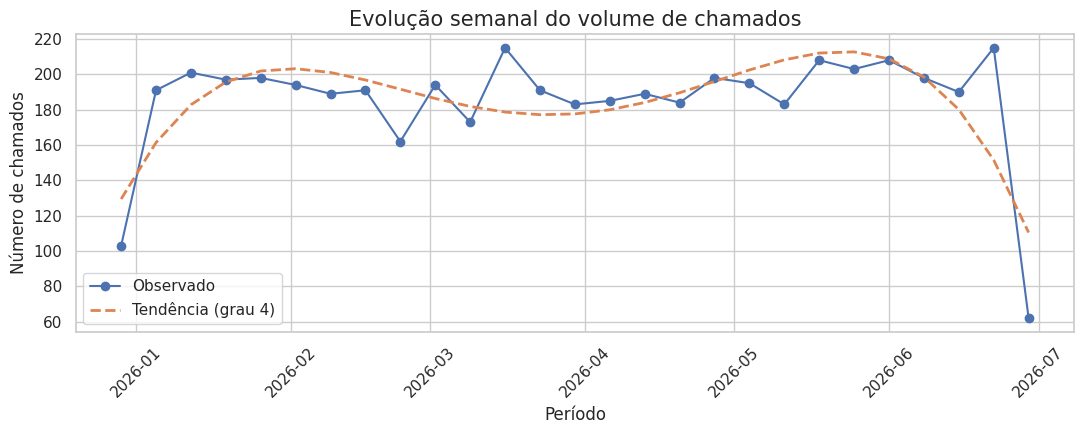

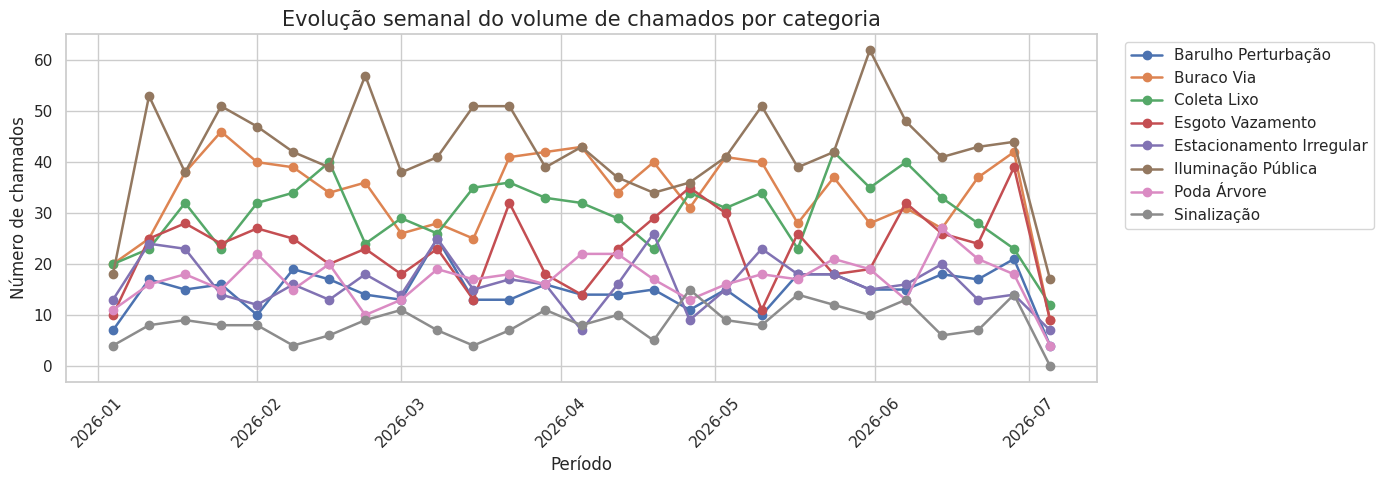

In [10]:
# Agrega o volume semanal total e por categoria para avaliar estabilidade temporal.
tabela_temporal_semana = df.groupby("week").size().reset_index(name="n_chamados")

plotar_linha_temporal(
    tabela_temporal_semana,
    "week",
    "n_chamados",
    "Evolução semanal do volume de chamados",
    "Número de chamados",
    "02_linha_volume_semanal"
)

plotar_linhas_temporais_por_grupo(
    df,
    "data_abertura",
    "categoria_real",
    "Evolução semanal do volume de chamados por categoria",
    "Número de chamados",
    "02_linha_volume_semanal_por_categoria",
    freq="W"
)

**<u>Resultados:</u>** 

- O volume semanal fica majoritariamente entre **180 e 215 chamados**, com quedas mais fortes nas semanas incompletas do início e do fim da janela.
- A tendência ajustada é relativamente estável ao longo do semestre, sem evidência visual de uma mudança estrutural de volume.
- Por categoria, `iluminação_publica` é a classe mais volumosa em quase todas as semanas e chega a picos próximos de **60 chamados semanais**. 
- Categorias como `sinalizacao` ficam frequentemente abaixo de **15 chamados por semana**, reforçando o risco de instabilidade em métricas por classe rara.

#### **2.3 Mapas por Bairros**

**Objetivo:** complementar a análise por bairro, mostrando se a demanda é concentrada espacialmente.

**Importância:** concentração geográfica pode gerar viés contextual: o modelo pode aprender padrões ligados a regiões específicas em vez de sinais realmente associados à categoria do serviço. \
Em outras palavras, isso importa porque bairro pode estar correlacionado com categoria e o modelo não deve depender excessivamente de padrões geográficos específicos.

---

In [11]:
# Baixa a malha de bairros do Rio e transforma os polígonos em um GeoDataFrame.
rio_bairro_url = "https://pgeo3.rio.rj.gov.br/arcgis/rest/services/Cartografia/Limites_administrativos/MapServer/4/query?where=1%3D1&outFields=nome,regiao_adm,codbairro_long&outSR=4326&f=json"
geo_json = requests.get(rio_bairro_url).json()
gdf_bairros = gpd.GeoDataFrame(
    ({
        "code": f["attributes"]["codbairro_long"],
        "regiao_adm": f["attributes"]["regiao_adm"].strip().lower(),
        "bairro": remove_accent(f["attributes"]["nome"].strip().lower()),
        "geometry": Polygon(f["geometry"]["rings"][0]),
    } for f in geo_json["features"]),
    geometry="geometry",
    crs="EPSG:4326",
)
gdf_bairros.head()

,code,regiao_adm,bairro,geometry
0,133,barra da tijuca,grumari,"POLYGON ((-43.50819 -23.03311, -43.50719 -23.0..."
1,137,realengo,jardim sulacap,"POLYGON ((-43.37541 -22.88962, -43.37542 -22.8..."
2,1,portuaria,saude,"POLYGON ((-43.18115 -22.89543, -43.18126 -22.8..."
3,84,madureira,vaz lobo,"POLYGON ((-43.32395 -22.85527, -43.32354 -22.8..."
4,91,ilha do governador,ribeira,"POLYGON ((-43.16461 -22.82115, -43.16459 -22.8..."


**<u>Resultados:</u>** 
- A prévia da malha confirma que os campos geográficos necessários estão disponíveis: `code`, `regiao_adm`, `bairro` e `geometry`.
- A normalização dos nomes de bairro é importante porque a junção com os chamados depende da coluna **bairro**; inconsistências aqui poderiam gerar regiões sem contagem ou mapas distorcidos.

In [18]:
# Agrupa sub-bairros da Ilha do Governador para compatibilizar a malha com a base de chamados.
codes = {"ilha do governador": [91,92,93,94,95,96,97,98,99,100,101,102,103,104]}  # Bairros da Ilha do Governador.
var = "regiao_adm"  # Alternativa possível: "regiao_adm".
if var == "bairro":
    code_to_bairro = {c: b for b, lst in codes.items() for c in lst}
    gdf_bairros["bairro"] = gdf_bairros["code"].map(code_to_bairro).fillna(gdf_bairros["bairro"])

In [19]:
# Funções para juntar chamados à malha e visualizar a distribuição espacial.
def juntar_chamados_com_malha(df: pd.DataFrame, gdf: gpd.GeoDataFrame, var: str = "bairro") -> gpd.GeoDataFrame:
    """Agrega chamados por bairro e junta o resultado à malha geográfica."""
    mapa = gdf.merge(df.groupby("bairro").size().rename("n_chamados"),
            left_on=var, right_index=True, how="left").fillna({"n_chamados": 0})
    return mapa


def plotar_mapa_bairros(mapa: gpd.GeoDataFrame, titulo: str, nome_arquivo: str) -> None:
    """Plota um mapa coroplético do volume total de chamados por bairro."""
    fig, ax = plt.subplots(figsize=(7,4))
    mapa.plot(
        column="n_chamados",
        cmap="Reds",
        linewidth=0.45,
        edgecolor="0.4",
        legend=True,
        ax=ax,
        missing_kwds={"color": "lightgrey", "label": "Sem correspondência"}
    )
    ax.set_title(titulo)
    ax.set_axis_off()
    save_figure(fig, fig_dir, nome_arquivo)
    plt.show()


def plotar_evolucao_mensal_bairros(df: pd.DataFrame, gdf: gpd.GeoDataFrame, title: str, nome_arquivo: str) -> None:
    """Plota mapas mensais para comparar a estabilidade espacial dos chamados."""
    periodos = sorted(df["month"].dropna().unique())
    ncols = 3
    nrows = math.ceil(len(periodos) / ncols)
    contagens_global = df.groupby(["month", "bairro"]).size().reset_index(name="n_chamados")
    vmax = contagens_global["n_chamados"].max()
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(-1)
    for i, periodo in enumerate(periodos):
        dados_periodo = df[df["month"] == periodo]
        mapa_periodo = juntar_chamados_com_malha(dados_periodo, gdf, var)
        mapa_periodo.plot(
            column="n_chamados",
            cmap="Reds",
            linewidth=0.45,
            edgecolor="0.45",
            vmin=0,
            vmax=vmax,
            ax=axes[i]
        )
        axes[i].set_title(pd.to_datetime(periodo).strftime("%m/%y"))
        axes[i].set_axis_off()
    for j in range(len(periodos), len(axes)):
        axes[j].set_visible(False)
    normalizador = Normalize(vmin=0, vmax=vmax)
    mapeavel = cm.ScalarMappable(norm=normalizador, cmap="Reds")
    mapeavel.set_array([])
    fig.colorbar(mapeavel, ax=axes[:len(periodos)], cax=fig.add_axes([0.99, 0.20, 0.018, 0.60]))
    fig.suptitle(title, y=0.93, fontsize=15)
    save_figure(fig, fig_dir, nome_arquivo)
    plt.show()

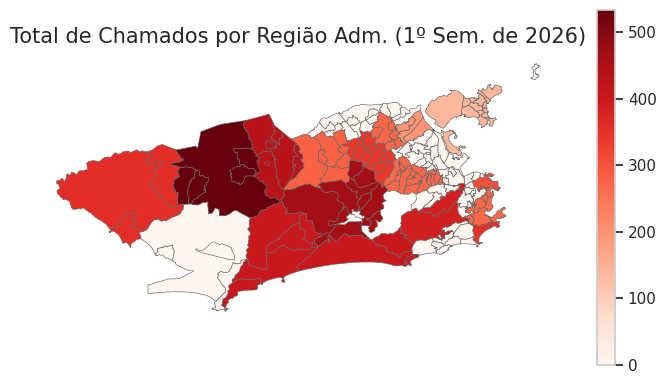

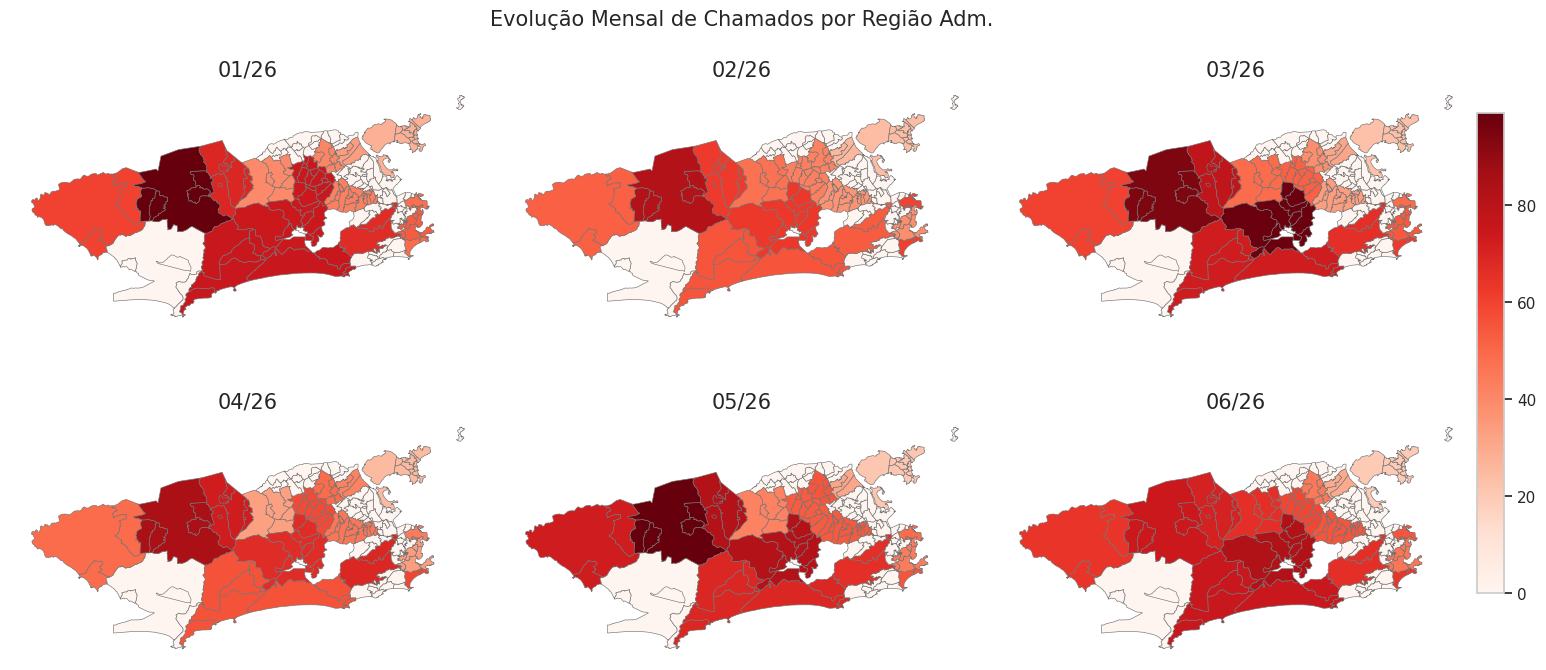

In [20]:
# Plota o mapa total e os mapas mensais para checar concentração espacial persistente.
mapa_bairros = juntar_chamados_com_malha(df, gdf_bairros,var)
name = "Bairro" if var == "bairro" else "Região Adm."

plotar_mapa_bairros(
    mapa_bairros,
    f"Total de Chamados por {name} (1º Sem. de 2026)",
    "02_mapa_volume_total_bairros"
)

plotar_evolucao_mensal_bairros(
    df,
    gdf_bairros,
    f"Evolução Mensal de Chamados por {name}",
    "02_mapa_evolucao_mensal_bairros",
)

**<u>Resultados:</u>**

- O mapa total reforça a concentração espacial já observada: áreas como `Campo Grande`, `Jacarepaguá`, `Bangu`, `Barra da Tijuca` e `Tijuca` aparecem entre os maiores volumes absolutos.
- Nos mapas mensais, os focos principais permanecem visualmente parecidos entre **01/26 e 06/26**, o que sugere estabilidade espacial razoável. 

---
---
### **3. Composição das Categorias por Subgrupo**

Esta seção verifica se a composição das categorias muda por canal, bairro ou mês. Quando isso acontece, métricas globais podem esconder falhas em subgrupos específicos.

---
---

In [21]:
# Funções para calcular percentuais e construir heatmaps anotados.
def aplicar_rotulos_eixo(eixo: Sequence[Any]) -> list[str]:
    """Aplica a função de rótulo amigável aos valores de um eixo."""
    return [pretty_label(valor) for valor in eixo]


def calcular_percentuais(tabela: pd.DataFrame, percentual_por: Literal["linha", "coluna", "total"] = "linha") -> pd.DataFrame:
    """Converte uma tabela absoluta em percentuais por linha, coluna ou total."""
    dados = tabela.copy().astype(float)
    if percentual_por == "linha":
        return dados.div(dados.sum(axis=1), axis=0) * 100
    if percentual_por == "coluna":
        return dados.div(dados.sum(axis=0), axis=1) * 100
    if percentual_por == "total":
        return dados / dados.values.sum() * 100
    raise ValueError("percentual_por deve ser 'linha', 'coluna' ou 'total'")


def plotar_heatmap(tabela: pd.DataFrame,
    titulo: str, xlabel: str, ylabel: str,
    nome_arquivo: str, cmap: str = "Blues", rotation: int = 45,
    formato_valor: str = ".0f", percentual_por: Literal["linha", "coluna", "total"] = "linha",
    fontsize_valor: int = 12, fontsize_percentual: int = 9, mostrar_porcentagem: bool = True) -> None:
    """Plota heatmap com valores absolutos e, quando solicitado, percentuais anotados."""
    dados_abs = tabela.copy()
    dados_pct = calcular_percentuais(dados_abs, percentual_por=percentual_por)

    dados_abs.index = aplicar_rotulos_eixo(dados_abs.index)
    dados_abs.columns = aplicar_rotulos_eixo(dados_abs.columns)
    dados_pct.index = dados_abs.index
    dados_pct.columns = dados_abs.columns

    fig, ax = plt.subplots(figsize=(max(9, 1.15 * dados_abs.shape[1]),max(5, 0.85 * dados_abs.shape[0])))
    sns.heatmap(dados_abs, annot=False, cmap=cmap, linewidths=0.5, ax=ax, cbar=True, square=True)
    limite_cor_texto = dados_abs.to_numpy().max() * 0.55

    for i in range(dados_abs.shape[0]):
        for j in range(dados_abs.shape[1]):
            valor = dados_abs.iloc[i, j]
            cor = "white" if valor >= limite_cor_texto else "#222222"
            if mostrar_porcentagem:
                percentual = dados_pct.iloc[i, j]
                ax.text(j + 0.5, i + 0.65, f"({percentual:.1f}%)",
                    ha="center", va="center", fontsize=fontsize_percentual, color=cor)

            ax.text(j + 0.5, i + 0.42, f"{valor:{formato_valor}}",
                    ha="center", va="center", fontsize=fontsize_valor, color=cor)

    ax.set_title(titulo)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.xticks(rotation=rotation, ha="right")
    plt.yticks(rotation=0)
    fig.tight_layout()
    save_figure(fig, fig_dir, nome_arquivo)

### **3.1 Heatmap de Categorias por Canal e Bairro**

**Propósito:** verificar se algumas categorias aparecem de forma concentrada em certos canais ou bairros.

**Importância:** diferenças fortes de composição sugerem que a avaliação do classificador deve ser segmentada. Caso contrário, um bom resultado médio pode ocultar desempenho fraco em canais, regiões ou categorias menos frequentes.

---

In [ ]:
# Cria tabelas de contingência entre categoria real e os principais subgrupos operacionais.
canal_categoria_abs = pd.crosstab(df["canal"], df["categoria_real"])
bairro_categoria_abs = pd.crosstab(df["bairro"], df["categoria_real"])

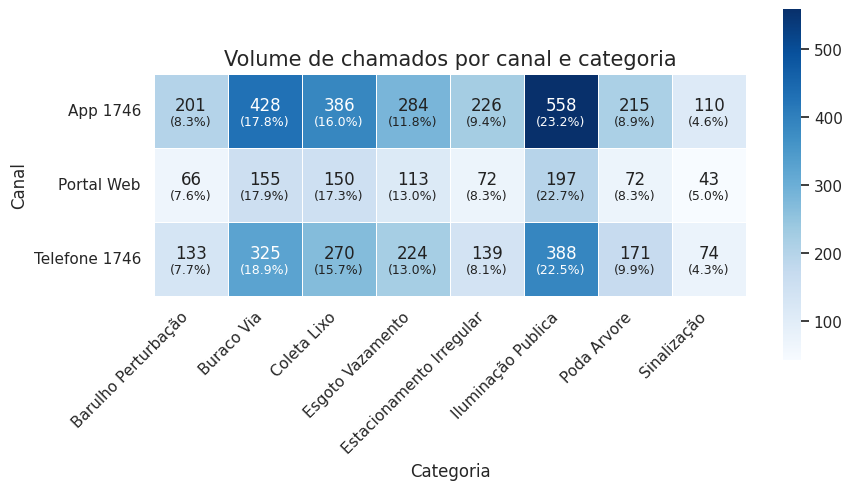

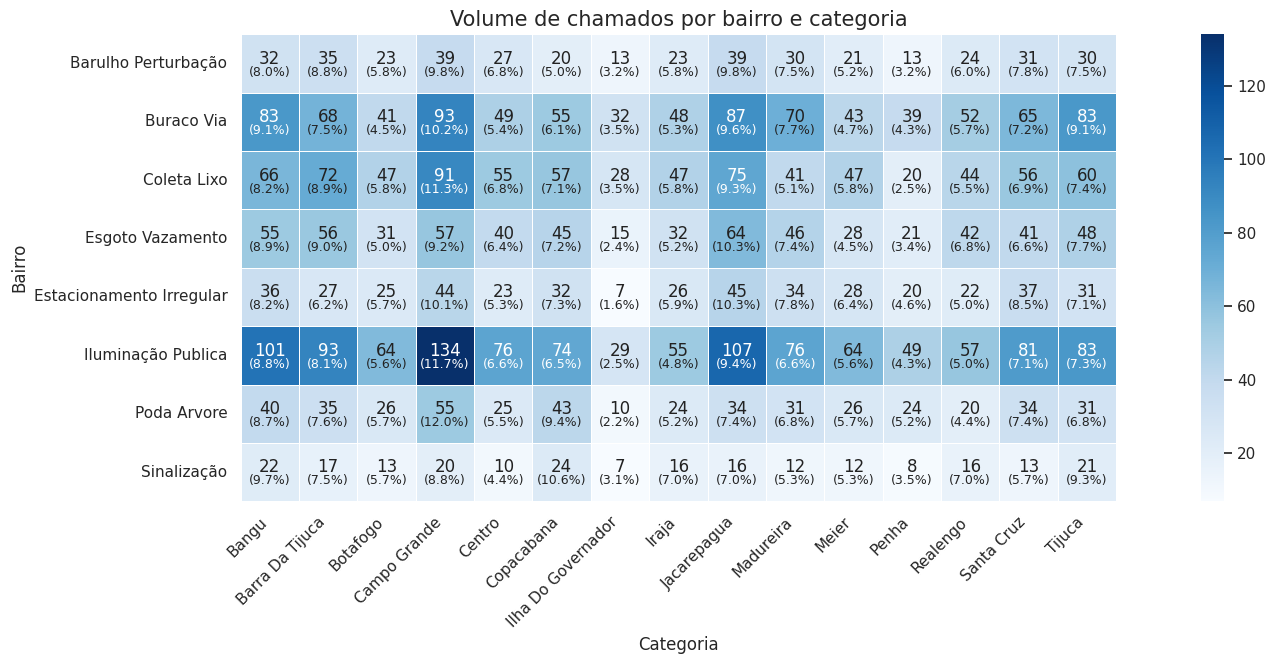

In [ ]:
# Plota heatmaps para comparar volumes absolutos e proporções por canal e por bairro.
plotar_heatmap(
    canal_categoria_abs,
    "Volume de chamados por canal e categoria",
    "Categoria","Canal",
    "03_heatmap_categoria_canal_absoluto",
    cmap="Blues"
)

plotar_heatmap(
    bairro_categoria_abs.T,
    "Volume de chamados por bairro e categoria",
    "Categoria","Bairro",
    "03_heatmap_categoria_bairro_absoluto",
    cmap="Blues"
)


**<u>Resultados:</u>**

- Por canal, a composição é parecida: `Iluminação Pública` é a maior categoria no `App 1746`, no `Telefone 1746` e no `Portal Web`. 

- `Sinalização` é pequena em todos os canais. Isso indica que o desbalanceamento é estrutural, não concentrado em um único canal.

- Por bairro, os maiores volumes se repetem nas categorias dominantes. Em `Campo Grande`, por exemplo, há **134 chamados de** `Iluminação Pública`, **93 de** `Buraco Via` e **91 de** `Coleta Lixo`. Em `Jacarepaguá`, esses valores também são altos: **107**, **87** e **75**, respectivamente. Essa concentração reforça a necessidade de olhar desempenho por bairro e categoria, não apenas a acurácia média.

### **3.2 Barras Empilhadas do Percentual de Categorias e Canais por Mês**

**Propósito:** verificar se a composição da base muda ao longo do tempo.

**Importância:** mudanças mensais de distribuição podem exigir monitoramento ou retreinamento. Se a proporção das categorias varia muito, o desempenho observado em um período pode não representar o comportamento futuro.

---

In [ ]:
# Função para visualizar a composição percentual mensal em barras empilhadas.
def plotar_barras_empilhadas_percentuais(
    tabela: pd.DataFrame, titulo: str, xlabel: str, ylabel: str, nome_arquivo: str,
    formatar_datas: bool = False) -> None:
    """Plota barras empilhadas percentuais a partir de uma tabela normalizada."""
    dados = tabela.copy()
    dados.index = pd.to_datetime(dados.index).strftime("%m/%y") if formatar_datas else aplicar_rotulos_eixo(dados.index)
    dados.columns = aplicar_rotulos_eixo(dados.columns)
    
    ax = dados.plot(kind="bar", stacked=True, figsize=(11, 5.5))
    ax.set(title=titulo, xlabel=xlabel, ylabel=ylabel)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.tick_params(axis="x", rotation=0)

    fig = ax.get_figure()
    fig.tight_layout()
    save_figure(fig, fig_dir, nome_arquivo)
    plt.show()

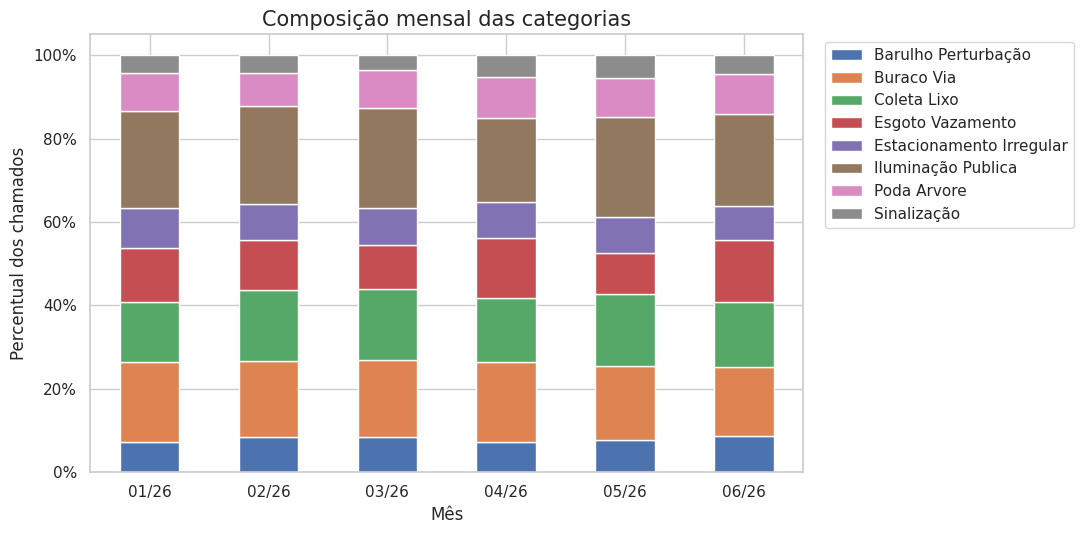

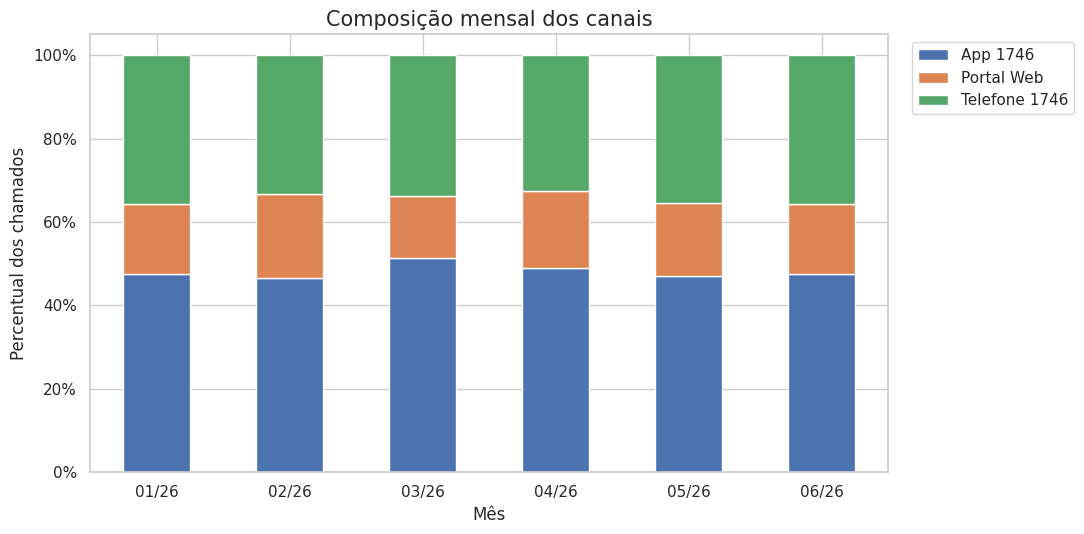

In [ ]:
# Calcula a composição mensal de categorias e canais para avaliar estabilidade temporal.
mes_categoria_pct_por_mes = pd.crosstab(df["month"], df["categoria_real"], normalize="index") * 100
mes_canal_pct_por_mes = pd.crosstab(df["month"], df["canal"], normalize="index") * 100

plotar_barras_empilhadas_percentuais(
    mes_categoria_pct_por_mes,
    "Composição mensal das categorias", "Mês", "Percentual dos chamados",
    "03_barras_empilhadas_categoria_por_mes", True)

plotar_barras_empilhadas_percentuais(
    mes_canal_pct_por_mes,
    "Composição mensal dos canais", "Mês", "Percentual dos chamados",
    "03_barras_empilhadas_canal_por_mes", True)

**<u>Resultados:</u>**

- A composição mensal das categorias permanece visualmente estável de **01/26 a 06/26**. A ordem geral se mantém próxima da distribuição agregada.

- A composição mensal dos canais também não muda drasticamente. O `App 1746` permanece como canal dominante em todos os meses, coerente com o agregado de **48,2%** da base; `Telefone 1746` fica em segundo lugar, próximo ao agregado de **34,5%**; e `Portal Web` segue como menor canal, próximo de **17,4%**. Isso reduz a suspeita de drift temporal forte na Parte 1.

---
---
### **4. Características dos Textos e Análise Lexical**

Como a tarefa é classificação textual, esta seção avalia se os textos têm informação suficiente, se há ruído relevante e se o vocabulário ajuda ou dificulta a separação entre categorias.

---
---

In [ ]:
# Lista de stopwords e termos genéricos removidos para destacar o vocabulário mais informativo.
STOPWORDS_PT = {
    "a", "à", "às", "ao", "aos", "aquela", "aquelas", "aquele", "aqueles", "aquilo",
    "as", "até", "com", "como", "da", "das", "de", "dela", "delas", "dele", "deles",
    "depois", "do", "dos", "e", "é", "ela", "elas", "ele", "eles", "em", "entre",
    "era", "eram", "essa", "essas", "esse", "esses", "esta", "está", "estão", "estas",
    "este", "estes", "eu", "foi", "foram", "há", "isso", "isto", "já", "lhe", "lhes",
    "mais", "mas", "me", "mesmo", "meu", "meus", "minha", "minhas", "muito", "na",
    "não", "nas", "nem", "no", "nos", "nós", "nossa", "nossas", "nosso", "nossos",
    "num", "numa", "o", "os", "ou", "para", "pela", "pelas", "pelo", "pelos",
    "por", "qual", "quando", "que", "quem", "se", "sem", "ser", "seu", "seus",
    "sua", "suas", "também", "tem", "têm", "tendo", "tenho", "ter", "teu", "teus",
    "tua", "tuas", "um", "uma", "umas", "uns", "vai", "vão", "você", "vocês",
    "favor", "solicito", "solicitar", "pedido", "chamado", "problema", "local",
    "rua", "avenida", "av", "r", "bairro", "próximo", "proximo", "frente"
}

In [ ]:
# Funções para limpar texto e medir sinais simples de qualidade textual
def limpar_texto_lexical(texto: Any) -> str:
    """Limpa o texto e mantém apenas tokens potencialmente informativos para análise lexical."""
    texto = "" if pd.isna(texto) else str(texto)
    texto = texto.lower()
    texto = unidecode(texto)
    texto = re.sub(r"http\S+|www\S+", " ", texto)  # Remove URLs iniciadas por http/https ou www
    texto = re.sub(r"\d+", " ", texto)  # Remove números, substituindo sequências numéricas por espaço
    texto = re.sub(r"[^a-záàâãéèêíïóôõöúçñ\s]", " ", texto)  # Remove pontuação, símbolos e caracteres fora do alfabeto esperado
    texto = re.sub(r"\s+", " ", texto).strip()  # Normaliza múltiplos espaços em um único espaço e remove espaços nas bordas
    tokens = [token for token in texto.split() if token not in STOPWORDS_PT and len(token) >= 3]
    return " ".join(tokens)


def proporcao_caixa_alta(texto: Any) -> float:
    """Calcula a proporção de letras maiúsculas em um texto."""
    texto = "" if pd.isna(texto) else str(texto)
    letras = re.findall(r"[A-Za-zÀ-ÿ]", texto)  # Extrai apenas letras, incluindo caracteres acentuados
    if len(letras) == 0:
        return 0
    maiusculas = [letra for letra in letras if letra.isupper()]
    return len(maiusculas) / len(letras)


# Cria variáveis textuais auxiliares usadas nas análises seguintes
df["texto_lexical"] = df["texto"].map(limpar_texto_lexical)
df["n_tokens_lexicais"] = df["texto_lexical"].str.split().str.len()
df["proporcao_caixa_alta"] = df["texto"].map(proporcao_caixa_alta)
# Indica chamados cujo texto ficou sem palavras úteis após limpeza lexical,
# ou seja, sem tokens informativos depois de remover URLs, números, símbolos, stopwords e termos muito curtos
df["texto_sem_tokens_uteis"] = df["n_tokens_lexicais"] == 0

#### **4.1 Estatísticas Qualitativas dos Textos**

**Objetivo:** medir se o material textual disponível para o modelo tem sinais mínimos de qualidade.

**Importância:** textos curtos ou sem tokens úteis prejudicam a classificação; excesso de caixa alta ou pontuação pode indicar ruído de entrada.

---

In [ ]:
# Resume indicadores de textos curtos, vazios após limpeza e com excesso de caixa alta.
variaveis_texto = ["tamanho_texto_caracteres", "tamanho_texto_palavras", "n_tokens_lexicais", "proporcao_caixa_alta",]

indicadores_texto = pd.DataFrame({
    "indicador": [
        "Textos com até 5 palavras",
        "Textos sem tokens úteis após limpeza",
        "Textos com mais de 30% de letras maiúsculas"
    ],
    "n": [
        int(df["bool_texto_curto"].sum()),
        int(df["texto_sem_tokens_uteis"].sum()),
        int((df["proporcao_caixa_alta"] > 0.30).sum())
    ]
})

indicadores_texto["percentual"] = 100 * indicadores_texto["n"] / len(df)
display(indicadores_texto)

,indicador,n,percentual
0,Textos com até 5 palavras,120,2.4
1,Textos sem tokens úteis após limpeza,0,0.0
2,Textos com mais de 30% de letras maiúsculas,0,0.0


**<u>Resultados:</u>**

- A base tem pouco ruído textual extremo e poucos casos com informação mínima. Para a etapa de modelagem, isso é positivo.

#### **4.2 Estatísticas Descritivas dos Textos**

**Objetivo:** descrever comprimento e dispersão dos textos no geral e por categoria.

**Importância:** diferenças grandes de extensão podem influenciar o desempenho do classificador e sugerir que algumas categorias trazem mais contexto textual do que outras.

---

In [ ]:
estatisticas_pt = {"mean": "Média", "median": "Mediana", "std": "Desvio Padrão", "min": "Mín", "max": "Máx"}
# Calcula estatísticas gerais e por categoria para o comprimento dos textos
def gerar_estatisticas_texto(
    df: pd.DataFrame, coluna_texto: str = "texto_limpo",
    coluna_categoria: str = "categoria_real") -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Calcula estatísticas de comprimento dos textos no geral e por categoria."""

    # Cria uma cópia do DataFrame para evitar alterações diretas na base original.
    # Também padroniza textos ausentes como string vazia antes de calcular os tamanhos.
    dados = (df.copy().assign(
            texto=lambda x: x[coluna_texto].fillna("").astype(str),
            comprimento_caracteres=lambda x: x["texto"].str.len(),
            numero_palavras=lambda x: x["texto"].str.split().str.len()))

    # Resume o tamanho dos textos em caracteres e palavras para toda a base.
    # O resultado ajuda a entender se os chamados têm informação textual suficiente para classificação.
    estatisticas_gerais = (
        dados[["comprimento_caracteres", "numero_palavras"]]
        .agg(["mean", "median", "std", "min", "max"])
        .T.rename(index={"comprimento_caracteres": "Comprimento (caracteres)", "numero_palavras": "Palavras"},
        columns=estatisticas_pt).reset_index(names="Métrica").round(2))

    # Calcula as mesmas estatísticas de comprimento por categoria real.
    # Isso permite identificar categorias com textos mais longos, curtos ou heterogêneos.
    estatisticas_por_categoria = (
        dados.groupby(coluna_categoria)["comprimento_caracteres"]
        .agg(["mean", "median", "std", "min", "max"])
        .rename(columns=estatisticas_pt).sort_values("Média", ascending=False).round(2))
    return estatisticas_gerais, estatisticas_por_categoria


estatisticas_gerais_texto, estatisticas_categoria_texto = gerar_estatisticas_texto(df)
display(estatisticas_gerais_texto)
display(estatisticas_categoria_texto)

,Métrica,Média,Mediana,Desvio Padrão,Mín,Máx
0,Comprimento (caracteres),128.25,156.0,57.12,24.0,199.0
1,Palavras,23.26,28.0,10.56,4.0,39.0


,Média,Mediana,Desvio Padrão,Mín,Máx
categoria_real,,,,,
esgoto_vazamento,134.63,161.0,56.06,29,199
poda_arvore,131.41,160.0,59.17,27,199
iluminacao_publica,129.98,160.0,59.55,28,193
buraco_via,127.47,154.0,58.88,24,197
estacionamento_irregular,127.00,150.0,53.66,29,192
coleta_lixo,125.45,156.0,54.59,27,178
sinalizacao,124.27,153.0,53.98,31,180
barulho_perturbacao,120.76,147.0,54.52,30,191


**<u>Resultados:</u>**

- As estatísticas descritivas dos textos indicam uma faixa controlada de tamanho.

- Por categoria, a maior média de comprimento aparece em `Esgoto Vazamento` (**134,63 caracteres**) e a menor em `Barulho Perturbação` (**120,76 caracteres**). \
A diferença de cerca de **14 caracteres** não é grande; portanto, o comprimento do texto sozinho provavelmente não separa bem as categorias, embora possa ajudar em alguns casos.

#### **4.3 Distribuição do Tamanho dos Textos**

**Objetivo:** visualizar se os chamados se concentram em frases curtas ou textos mais detalhados.

**Importância:** textos muito curtos podem ser difíceis de separar entre categorias; textos longos podem trazer contexto, mas também ruído.

---

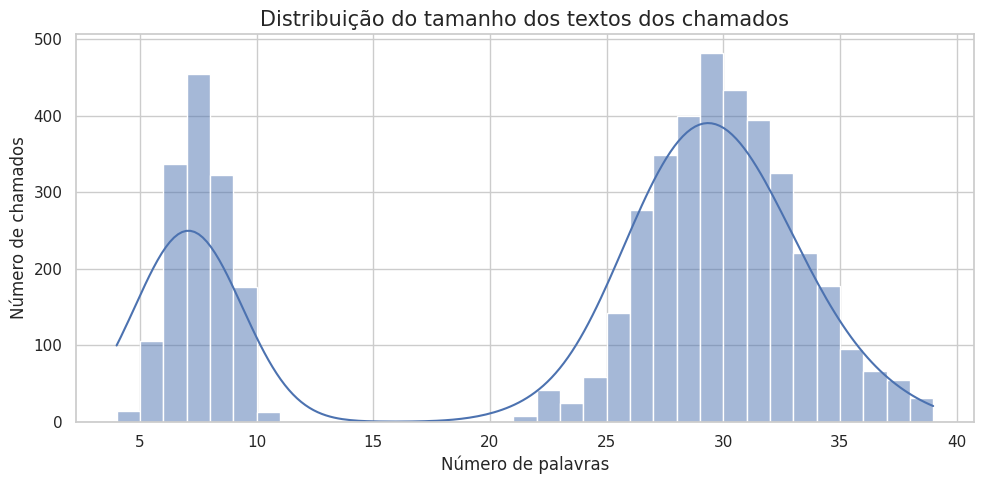

In [ ]:
# Plota a distribuição do tamanho dos textos em número de palavras.
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df["tamanho_texto_palavras"], bins=35, kde=True, ax=ax)
ax.set_title("Distribuição do tamanho dos textos dos chamados")
ax.set_xlabel("Número de palavras")
ax.set_ylabel("Número de chamados")
save_figure(fig, fig_dir, "04_histograma_tamanho_texto_palavras.png")
plt.show()

**<u>Resultados:</u>**

- O histograma sugere uma distribuição bimodal! Dois grupos de textos: um grupo curto, por volta de **7 a 9 palavras**, e outro mais detalhado, concentrado perto de **28 a 32 palavras**. Como a mediana é **28 palavras**, a maior parte informativa está no segundo grupo. 
- Na avaliação dos classificadores, vale verificar se os erros aumentam nos textos curtos, porque eles carregam menos contexto para diferenciar categorias parecidas.

#### **4.4 Bigramas e Trigramas mais Frequentes**

<u>n-gramas</u> são sequências de palavras que aparecem juntas no texto. Um **bigrama** é uma sequência de 2 palavras, como `"coleta lixo"`, enquanto um **trigrama** é uma sequência de 3 palavras, como `"falta iluminação pública"`. Eles ajudam a capturar expressões completas.

**Objetivo:** identificar expressões recorrentes no corpus após limpeza textual.

**Importância:** n-gramas ajudam a entender quais termos de serviço, tempo e localização podem estar guiando o classificador \
 — e também onde existe risco de o modelo aprender atalhos excessivamente específicos.

---

In [ ]:
# Funções para calcular frequências de n-gramas e plotar os termos mais recorrentes.
def obter_frequencias_ngrams(textos: pd.Series, ngram_range: Tuple[int, int] = (1, 1),
                            max_features: int = 30,min_df: int = 2) -> pd.DataFrame:
    """Calcula a frequência dos n-gramas mais comuns em uma série de textos."""

    # Configura o vetorizador para contar termos ou combinações de termos nos textos.
    # ngram_range=(1, 1) conta palavras isoladas; (2, 2) conta pares de palavras.
    vectorizer = CountVectorizer(ngram_range=ngram_range, 
                                max_features=max_features,
                                min_df=min_df)
    # Transforma os textos em uma matriz documento-termo com contagens de ocorrência.
    matriz = vectorizer.fit_transform(textos) 
    # Soma as ocorrências de cada termo ao longo de todos os chamados.
    frequencias = np.asarray(matriz.sum(axis=0)).ravel()
    # Recupera os nomes dos termos associados às colunas da matriz.
    termos = vectorizer.get_feature_names_out()
    # Organiza termos e frequências em uma tabela ordenável.
    tabela = pd.DataFrame({"termo": termos, "frequencia": frequencias})
    # Retorna os termos mais frequentes em ordem decrescente.
    return tabela.sort_values("frequencia", ascending=False).reset_index(drop=True)


def plotar_top_termos(tabela: pd.DataFrame, titulo: str, nome_arquivo: str, top_n: int = 25) -> None:
    """Plota os termos mais frequentes em barras horizontais."""
    # Seleciona os termos mais frequentes e reordena para facilitar a leitura no gráfico horizontal.
    dados = tabela.head(top_n).sort_values("frequencia", ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(5, 0.34 * len(dados))))
    ax.barh(dados["termo"], dados["frequencia"])
    # Define título e rótulos do gráfico
    ax.set_title(titulo)
    ax.set_xlabel("Frequência")
    ax.set_ylabel("")
    for i, valor in enumerate(dados["frequencia"]):
        ax.text(valor, i, f" {int(valor)}", va="center")
    save_figure(fig, fig_dir, nome_arquivo)
    plt.show()

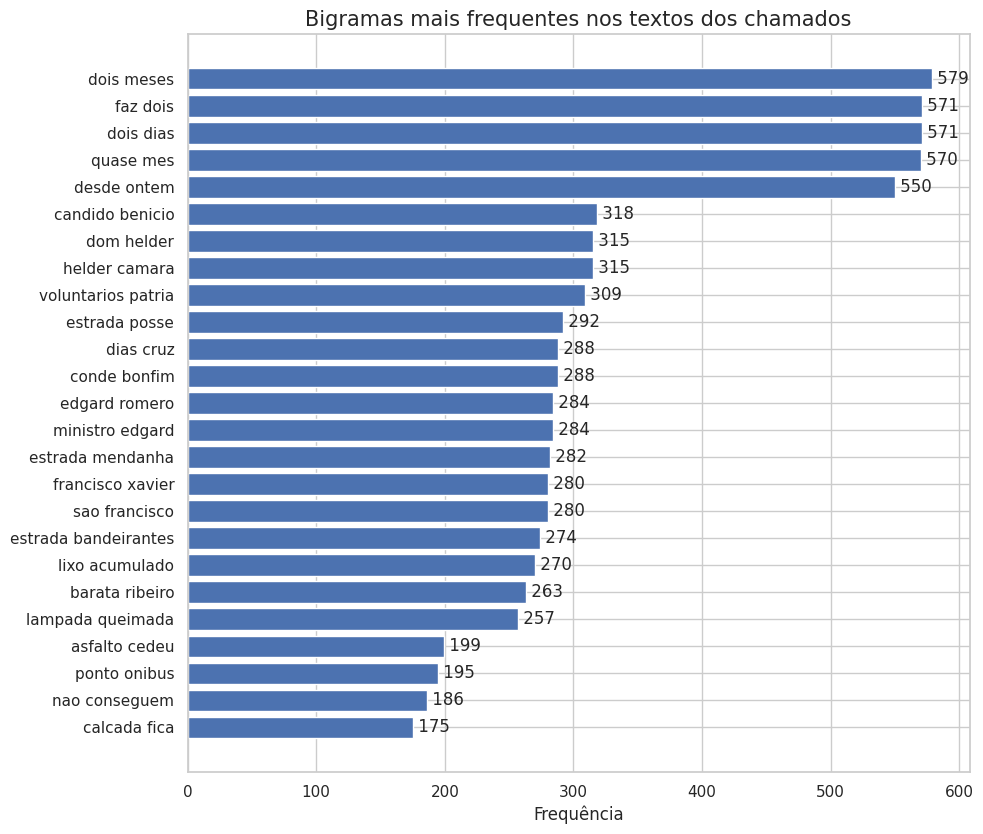

In [ ]:
# Calcula e plota os bigramas mais frequentes nos textos com tokens úteis.
textos_lexicais = df.loc[df["texto_lexical"].str.len() > 0, "texto_lexical"]
frequencia_bigramas = obter_frequencias_ngrams(textos_lexicais, ngram_range=(2, 2), max_features=40, min_df=2)

plotar_top_termos(
frequencia_bigramas,
"Bigramas mais frequentes nos textos dos chamados",
"04_bigramas_mais_frequentes.png",
top_n=25
)

**<u>Resultados:</u>**

- Os bigramas mais frequentes são fortemente ligados a tempo e recorrência do problema: **"dois meses" (579)**, **"faz dois" (571)**, **"dois dias" (571)**, **"quase mes" (570)** e **"desde ontem" (550)**. 

- Termos mais ligados ao serviço aparecem depois, como **"lixo acumulado" (270)**, **"lampada queimada" (257)**, **"asfalto cedeu" (199)** e **"ponto onibus" (195)**. Isso indica que o texto contém sinais úteis, mas parte relevante do vocabulário recorrente descreve urgência ou duração, não necessariamente a categoria.

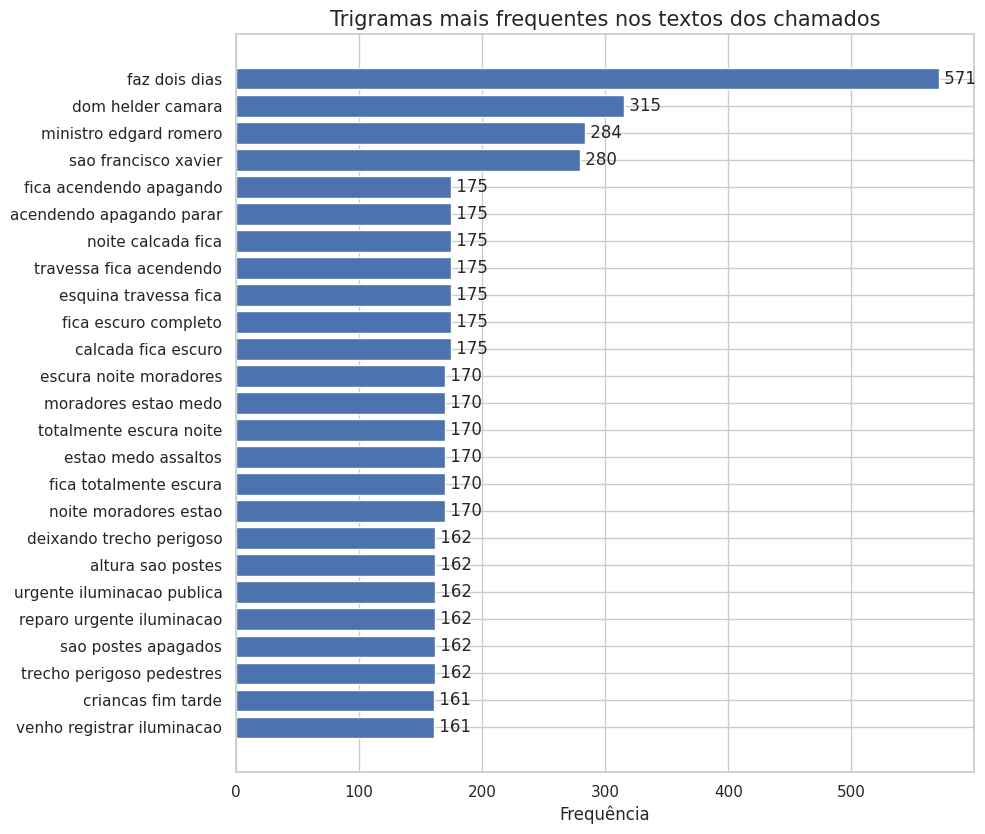

In [ ]:
# Calcula e plota os trigramas mais frequentes nos textos com tokens úteis.
frequencia_trigramas = obter_frequencias_ngrams(textos_lexicais, ngram_range=(3, 3), max_features=40, min_df=2)

plotar_top_termos(
    frequencia_trigramas,
    "Trigramas mais frequentes nos textos dos chamados",
    "04_trigramas_mais_frequentes.png",
    top_n=25
)

**<u>Resultados:</u>** 

- Nos trigramas, aparecem tanto padrões temporais quanto endereços e expressões específicas. O mais frequente é **"faz dois dias" (571)**; em seguida vêm referências de localização como **"dom helder camara" (315)**, **"ministro edgard romero" (284)** e **"sao francisco xavier" (280)**.

- Também surgem expressões úteis para serviço, como **"fica acendendo apagando" (175)** e **"urgente iluminacao publica" (162)**. Esse padrão sugere sinal lexical real, mas também risco de o modelo aprender atalhos associados a logradouros.

#### **4.5 Matriz de Similaridade das Categorias (TF-IDF)**

Nesta subseção, agregamos os textos de cada `categoria_real`, representamos esse vocabulário por meio de TF-IDF e calculamos a similaridade cosseno entre as categorias. Em termos práticos, a análise mostra quais categorias usam palavras e expressões mais parecidas entre si.\
_(TF-IDF é uma forma de transformar texto em números dando mais peso às palavras que são importantes para diferenciar um texto dos outros)_

**Objetivo:** medir quanto o vocabulário agregado das categorias se sobrepõe.

**Importância:** categorias com alta similaridade lexical tendem a gerar confusões mais prováveis. Essa análise ajuda a interpretar erros esperados e a verificar se ganhos de um novo modelo aparecem justamente nas fronteiras mais difíceis.

---

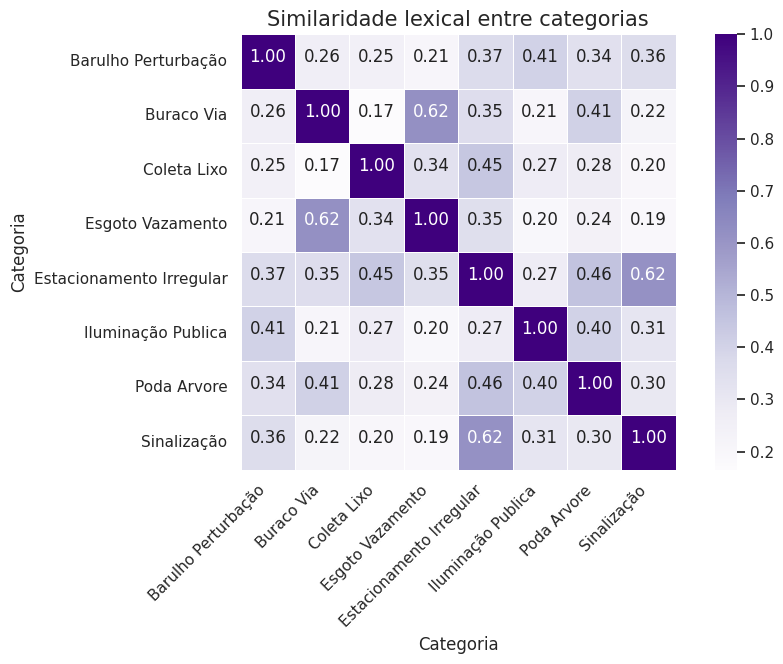

In [ ]:
# Calcula a similaridade lexical entre categorias usando TF-IDF e cosseno.
def matriz_similaridade_categorias(
    df: pd.DataFrame,
    coluna_categoria: str = "categoria_real",
    coluna_texto: str = "texto_lexical",
    ngram_range: Tuple[int, int] = (1, 2),
    min_df: int = 2,
) -> pd.DataFrame:
    """Agrega textos por categoria e calcula a similaridade cosseno entre elas."""
    # Junta todos os textos de uma mesma categoria em um único documento agregado
    textos_categoria = (df.groupby(coluna_categoria)[coluna_texto].apply(
        lambda textos: " ".join(textos.dropna().astype(str))).reset_index())
    
    # Cria uma representação TF-IDF dos textos agregados por categoria.
    vectorizer = TfidfVectorizer(
        ngram_range=ngram_range,  # Considera palavras isoladas e/ou combinações de palavras, conforme definido
        min_df=min_df, # Ignora termos muito raros, que aparecem em menos documentos do que esse limite
        max_features=2500)
    
    # Transforma os textos agregados em uma matriz numérica categoria x termos.
    matriz = vectorizer.fit_transform(textos_categoria[coluna_texto])

    # Calcula a similaridade cosseno entre os vetores TF-IDF das categorias
    # Valores próximos de 1 indicam vocabulários mais parecidos
    similaridade = cosine_similarity(matriz)
    tabela = pd.DataFrame(
        similaridade,
        index=textos_categoria[coluna_categoria],
        columns=textos_categoria[coluna_categoria])
    return tabela

# Calcula a matriz de similaridade lexical entre as categorias reais dos chamados
similaridade_categorias = matriz_similaridade_categorias(df)
# Plota a matriz como heatmap
plotar_heatmap(similaridade_categorias,
    "Similaridade lexical entre categorias","Categoria","Categoria",
    "04_heatmap_similaridade_lexical_categorias",
    formato_valor=".2f",cmap="Purples",mostrar_porcentagem=False
)

**<u>Resultados:</u>** 

- A matriz mostra pares de categorias com sobreposição lexical relevante. Os maiores fora da diagonal são **Buraco Via x Esgoto Vazamento (0,62)** e **Estacionamento Irregular x Sinalização (0,62)**.

- Também aparecem similaridades moderadas entre **Estacionamento Irregular x Poda Árvore (0,46)** e **Coleta Lixo x Estacionamento Irregular (0,45)**. Esses pares devem receber atenção especial na Parte 2, porque são candidatos naturais a erros de confusão entre classes.

---
---

## **Achados mais relevantes**

1. **A base está íntegra e adequada para avaliação inicial.** São 5.000 chamados, sem valores faltantes e sem IDs duplicados. O período cobre **01/01/2026 a 30/06/2026**, com 8 categorias, 15 bairros e 3 canais. Isso é uma base limpa para comparar os classificadores sem ruído óbvio de qualidade de dados.

2. **O principal risco para métricas globais é o desbalanceamento entre categorias.** `Iluminação Pública`, `Buraco Via` e `Coleta Lixo` somam **57,2%** dos chamados, já `Sinalização` só **4,5%**. \
⇒ Por isso, acurácia isolada pode favorecer o modelo que acerta bem as classes maiores e esconder perda nas menores.

3. **Canal e bairro importam para a auditoria dos modelos.** O `App 1746` responde por **48,2%** da base, enquanto o `Portal Web` tem **17,4%**. \
Em bairros, o volume bruto favorece `Campo Grande (533)`, `Jacarepaguá (467)` e `Bangu (435)`, mas a taxa por população destaca `Centro` (129 p/ 10 mil hab.), `Madureira` (86) e `Méier` (68).\
⇒ A avaliação deve checar se o desempenho se mantém nesses subgrupos.

4. **A base textual é boa, mas há dois regimes de tamanho.** Apenas 2,4% dos textos têm até 5 palavras e não há textos sem tokens úteis após limpeza. Mesmo assim, o histograma sugere um grupo curto, perto de **7 a 9 palavras**, e outro mais detalhado, perto de **28 a 32 palavras**.\
⇒ Isso recomenda comparar erros por tamanho de texto.

5. **Há sinal lexical útil, mas também sobreposição entre classes.** Expressões como **"lixo acumulado"**, **"lampada queimada"** e **"asfalto cedeu"** ajudam a separar categorias, mas a similaridade é alta em pares como **Buraco Via x Esgoto Vazamento (0,62)** e **Estacionamento Irregular x Sinalização (0,62)**. \
⇒ Devemos monitorar esses pares nas matrizes de confusão dos modelos A e B.